# Capítulo 3 — La PSF: degradación, convolución y deconvolución

## Objetivo del notebook

Este capítulo es uno de los más importantes de todo el curso, porque aquí aparece con claridad el **problema inverso**.

En el capítulo anterior estudiamos el modelo de formación de imagen:

$$
g(x,y)=f(x,y)*h(x,y)+n(x,y)
$$

donde:

- $f(x,y)$ es el objeto original
- $h(x,y)$ es la PSF del sistema
- $*$ representa la convolución
- $n(x,y)$ es el ruido
- $g(x,y)$ es la imagen observada

Hasta ahora nos habíamos concentrado en la parte “hacia adelante” del problema:

> dado un objeto y una PSF, ¿cómo se forma la imagen?

Ahora cambiaremos de perspectiva y nos preguntaremos:

> dada una imagen degradada, ¿cómo intentamos recuperar el objeto original?

Ese intento de inversión recibe el nombre de **deconvolución**.

---

## Ideas clave del capítulo

En este notebook vamos a desarrollar cinco ideas centrales:

1. la PSF controla la degradación espacial de la imagen  
2. la convolución mezcla información vecina  
3. en Fourier, la convolución se convierte en multiplicación  
4. invertir el sistema no es trivial, porque la información se atenúa o se pierde  
5. la deconvolución directa es inestable, por lo que se necesitan métodos más robustos


## 1. ¿Por qué la PSF es tan importante?

La PSF (*Point Spread Function*) describe la respuesta del sistema a un punto.

Eso parece una definición pequeña, pero sus consecuencias son enormes.

Si un solo punto se dispersa según una cierta forma, entonces cualquier objeto, por linealidad, se formará como la superposición de muchos puntos dispersados.

Por eso la PSF:

- determina la nitidez del sistema
- controla cuánto se expanden los detalles finos
- afecta el contraste
- condiciona qué tan recuperable es una imagen

En términos prácticos:

> conocer la PSF es conocer la “firma” del sistema óptico.


## 2. Convolución: interpretación física y matemática

La ecuación

$$
g(x,y)=f(x,y)*h(x,y)
$$

significa que la imagen observada es el resultado de mezclar localmente el objeto con la PSF.

La convolución puede interpretarse así:

- cada píxel del objeto “reparte” su energía según la forma de la PSF
- la imagen final es la suma de todas esas contribuciones
- si la PSF es ancha, la información se dispersa más
- si la PSF es muy concentrada, la imagen conserva más nitidez

En otras palabras:

> la convolución no destruye arbitrariamente la imagen; la redistribuye espacialmente de acuerdo con la respuesta del sistema.

Sin embargo, esa redistribución suele hacer más difícil distinguir detalles finos.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

plt.rcParams["figure.figsize"] = (6, 5)
plt.rcParams["image.cmap"] = "gray"


## 3. Construcción de una imagen de prueba

Para estudiar el efecto de la PSF y la deconvolución, construiremos una imagen sencilla pero informativa.

No usaremos solo un cuadrado. Vamos a incluir varias estructuras:

- un cuadrado grande
- una línea delgada
- dos puntos brillantes cercanos
- una región rectangular

Esto es útil porque no todas las estructuras reaccionan igual al blur.


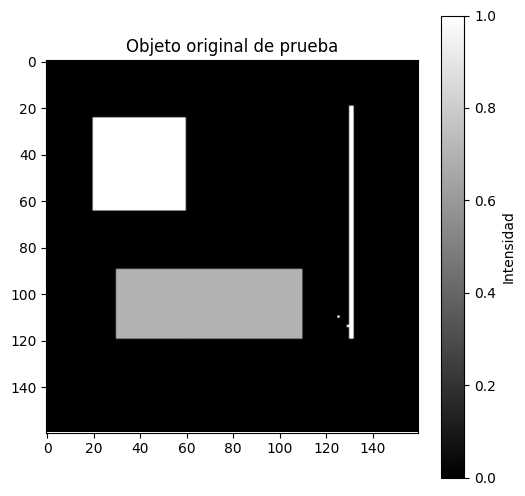

In [2]:
img = np.zeros((160, 160), dtype=float)

# cuadrado
img[25:65, 20:60] = 1.0

# rectángulo
img[90:120, 30:110] = 0.7

# línea delgada vertical
img[20:120, 130:132] = 1.0

# dos puntos cercanos
img[110, 125] = 1.0
img[114, 129] = 1.0

plt.figure(figsize=(6,6))
plt.imshow(img, vmin=0, vmax=1)
plt.title("Objeto original de prueba")
plt.colorbar(label="Intensidad")
plt.show()


### Interpretación

Esta imagen contiene información con distintas escalas espaciales:

- regiones grandes y homogéneas
- bordes bien definidos
- estructuras delgadas
- puntos pequeños y cercanos

Eso permite observar qué tipo de información se degrada más fuertemente.


## 4. Construcción de la PSF gaussiana

Usaremos una PSF gaussiana porque ofrece un modelo muy útil para representar desenfoques suaves.

Matemáticamente:

$$
h(x,y)=A\exp\left(-\frac{x^2+y^2}{2\sigma^2}\right)
$$

donde:

- el máximo está en el centro
- la energía decrece con la distancia
- el parámetro $\sigma$ controla la extensión del desenfoque

Después normalizaremos la PSF para que la suma total sea 1.


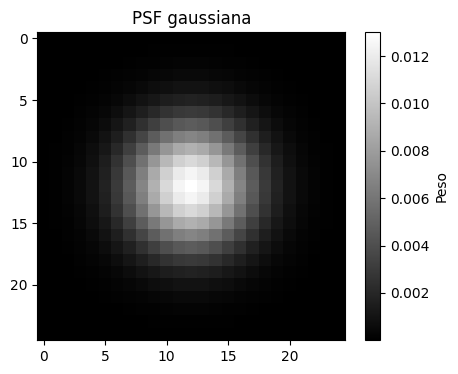

Shape: (25, 25)
Suma: 0.9999999999999999
Máximo: 0.013001052105756392


In [3]:
def gaussian_psf(size=25, sigma=3.5):
    ax = np.arange(-(size // 2), size // 2 + 1)
    xx, yy = np.meshgrid(ax, ax)
    psf = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    psf /= psf.sum()
    return psf

psf = gaussian_psf(size=25, sigma=3.5)

plt.figure(figsize=(5,4))
plt.imshow(psf)
plt.title("PSF gaussiana")
plt.colorbar(label="Peso")
plt.show()

print("Shape:", psf.shape)
print("Suma:", psf.sum())
print("Máximo:", psf.max())


## 5. Visualización 3D de la PSF

La PSF gaussiana no es plana como la PSF caja.  
Tiene forma de “montaña”: alta en el centro y decreciente hacia afuera.

Esa geometría es importante porque indica que los vecinos más cercanos contribuyen más que los lejanos.


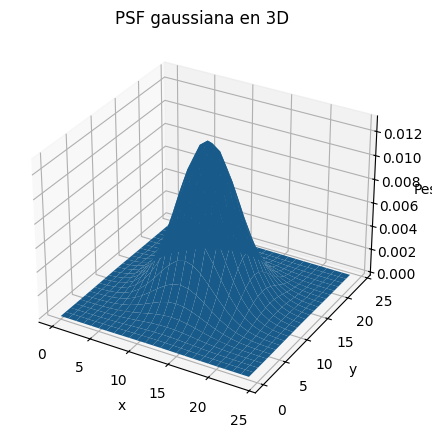

In [4]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

X = np.arange(psf.shape[1])
Y = np.arange(psf.shape[0])
X, Y = np.meshgrid(X, Y)

fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, psf)
ax.set_title("PSF gaussiana en 3D")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("Peso")
plt.show()


## 6. Aplicar la convolución: formación de imagen degradada

Ahora simulamos la formación de imagen:

$$
g(x,y)=f(x,y)*h(x,y)
$$

Todavía no añadiremos ruido.  
Primero queremos aislar únicamente el efecto del blur.


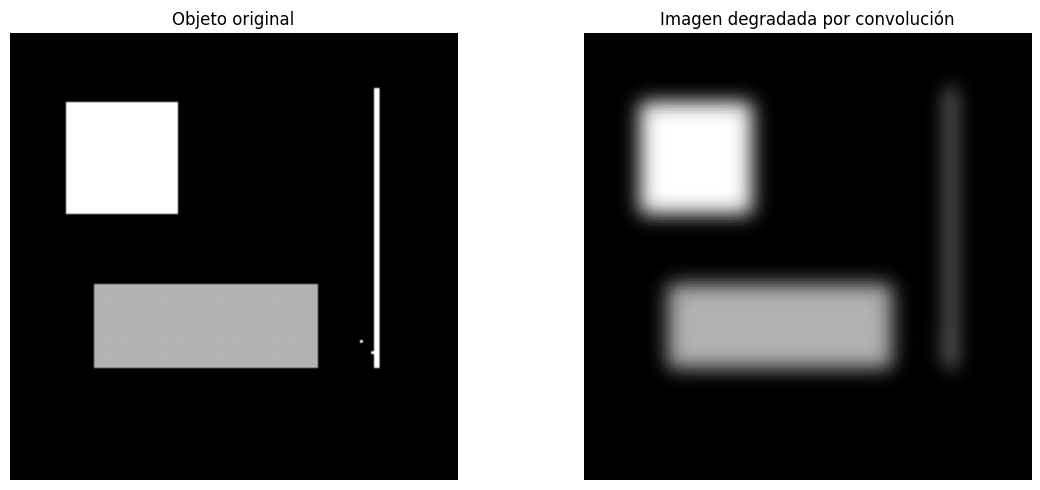

In [5]:
img_blur = convolve2d(img, psf, mode="same", boundary="fill", fillvalue=0)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, vmin=0, vmax=1)
plt.title("Objeto original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_blur, vmin=0, vmax=1)
plt.title("Imagen degradada por convolución")
plt.axis("off")

plt.tight_layout()
plt.show()


### ¿Qué cambió?

Después de la convolución:

- los bordes ya no son abruptos
- las líneas delgadas pierden contraste
- los puntos cercanos comienzan a mezclarse
- las transiciones espaciales se suavizan

Este es el efecto típico de una PSF que actúa como filtro pasa-bajas.


## 7. Comparación de perfiles

Para ver con más claridad la degradación, comparemos perfiles horizontales de una fila donde haya estructura.


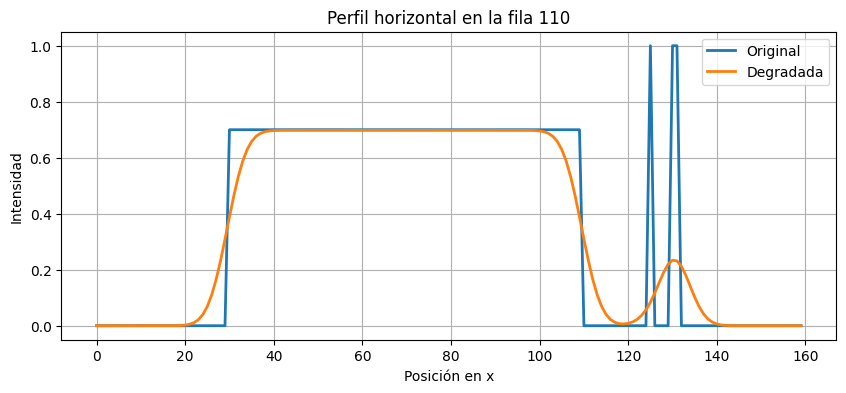

In [6]:
fila_idx = 110

perfil_original = img[fila_idx, :]
perfil_blur = img_blur[fila_idx, :]

plt.figure(figsize=(10,4))
plt.plot(perfil_original, label="Original", linewidth=2)
plt.plot(perfil_blur, label="Degradada", linewidth=2)
plt.title(f"Perfil horizontal en la fila {fila_idx}")
plt.xlabel("Posición en x")
plt.ylabel("Intensidad")
plt.grid(True)
plt.legend()
plt.show()


En esta comparación se ve que la convolución:

- reduce las pendientes abruptas
- ensancha estructuras pequeñas
- mezcla picos cercanos
- redistribuye energía espacial

Ese comportamiento es la esencia de la degradación por PSF.


## 8. Introducir ruido

En una situación real, la imagen observada no solo está borrosa.  
También contiene ruido.

Agregaremos ruido gaussiano aditivo para acercarnos a un caso más realista:

$$
g(x,y)=f(x,y)*h(x,y)+n(x,y)
$$


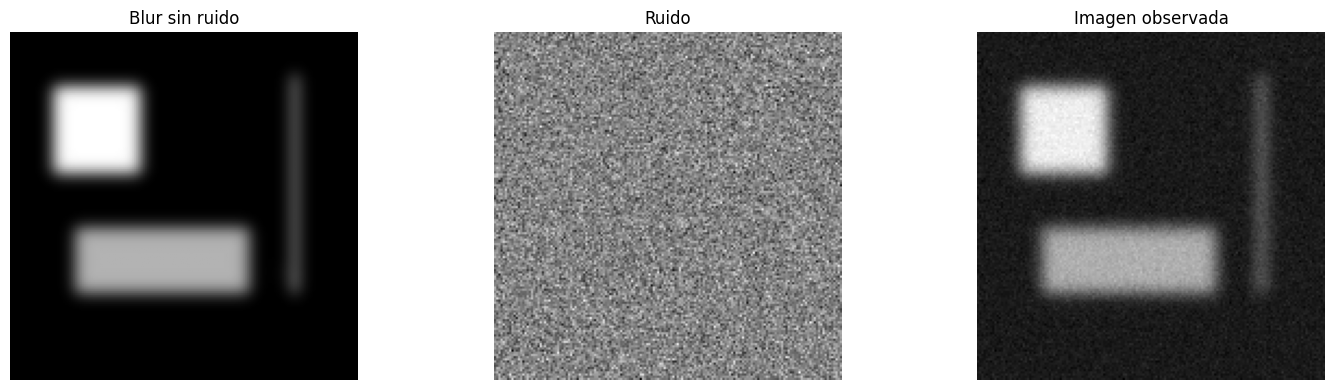

In [7]:
np.random.seed(7)
noise_sigma = 0.03
noise = np.random.normal(0, noise_sigma, img.shape)
img_obs = img_blur + noise

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img_blur)
plt.title("Blur sin ruido")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(noise)
plt.title("Ruido")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(img_obs)
plt.title("Imagen observada")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. El problema inverso

Ahora sí aparece el núcleo del capítulo.

Sabemos que la imagen observada se obtuvo mediante:

$$
g=f*h+n
$$

Pero nosotros queremos recuperar $f$.

Ese intento es el problema inverso.

¿Por qué es difícil?

Porque el sistema ha hecho dos cosas:

1. ha redistribuido espacialmente la energía  
2. ha añadido incertidumbre por ruido  

Por lo tanto, recuperar exactamente la imagen original no suele ser posible de forma perfecta.


## 10. Convolución en espacio, multiplicación en Fourier

Aquí aparece una herramienta decisiva.

Si aplicamos transformada de Fourier, entonces:

$$
G(f_x,f_y)=F(f_x,f_y)H(f_x,f_y)
$$

Esto es poderosísimo, porque transforma una convolución en una multiplicación.

En principio, uno podría pensar:

$$
F(f_x,f_y)=\frac{G(f_x,f_y)}{H(f_x,f_y)}
$$

y luego invertir la transformada.

Eso sería la idea más directa de deconvolución.


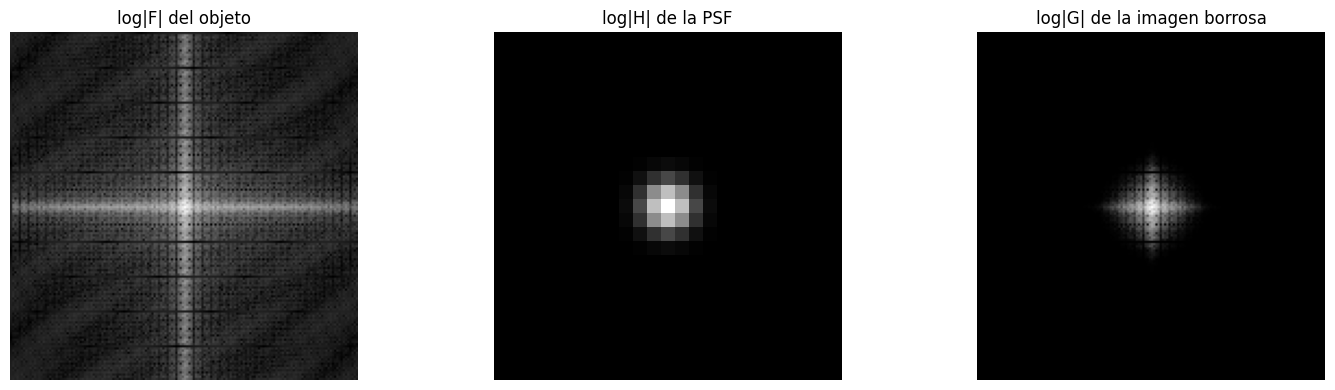

In [8]:
def fft2c(x):
    return np.fft.fftshift(np.fft.fft2(x))

def ifft2c(X):
    return np.fft.ifft2(np.fft.ifftshift(X))

F = fft2c(img)
H = fft2c(psf)
G = fft2c(img_blur)

def log_mag(X):
    return np.log1p(np.abs(X))

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(log_mag(F))
plt.title("log|F| del objeto")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(log_mag(H))
plt.title("log|H| de la PSF")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(log_mag(G))
plt.title("log|G| de la imagen borrosa")
plt.axis("off")

plt.tight_layout()
plt.show()


### Interpretación

Esta visualización permite ver algo fundamental:

- el objeto tiene contenido frecuencial amplio
- la PSF tiene una respuesta concentrada en bajas frecuencias
- la imagen degradada refleja la atenuación de componentes altas

Dicho de otra forma:

> el blur elimina o reduce detalles finos porque atenúa las altas frecuencias.


## 11. Deconvolución directa en Fourier

Primero implementaremos la idea más simple:

$$
\hat{F}=\frac{G}{H}
$$

y después aplicaremos transformada inversa.

Este método es útil pedagógicamente, pero tiene un problema serio: es muy inestable.


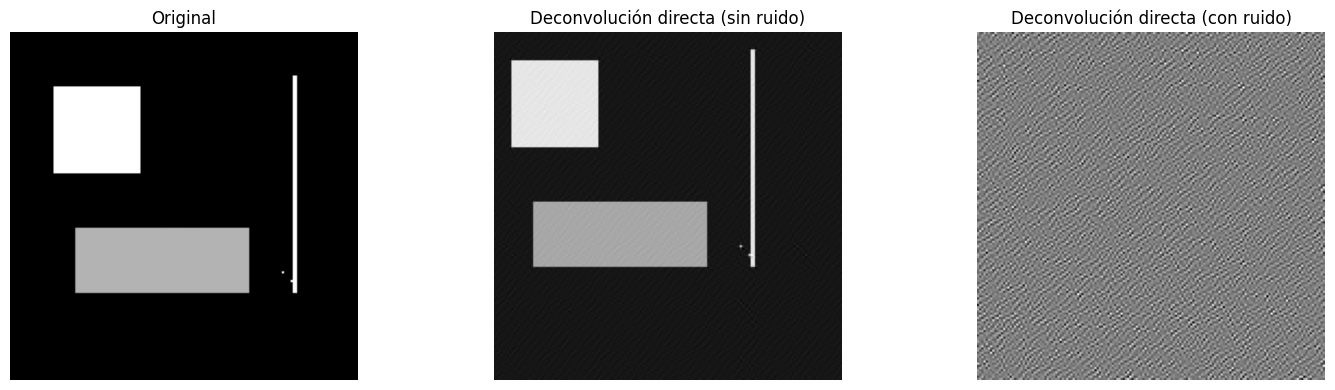

In [9]:
def direct_fourier_deconv(g, h, eps=1e-8):
    G = np.fft.fft2(g)
    H = np.fft.fft2(h, s=g.shape)
    F_est = G / (H + eps)
    f_est = np.real(np.fft.ifft2(F_est))
    return f_est

rec_direct_clean = direct_fourier_deconv(img_blur, psf)
rec_direct_noisy = direct_fourier_deconv(img_obs, psf)

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img, vmin=0, vmax=1)
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(rec_direct_clean)
plt.title("Deconvolución directa (sin ruido)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(rec_direct_noisy)
plt.title("Deconvolución directa (con ruido)")
plt.axis("off")

plt.tight_layout()
plt.show()


## 12. ¿Por qué falla la deconvolución directa?

La razón es profunda y muy importante.

En Fourier, la deconvolución requiere dividir por $H$.

Pero la respuesta frecuencial del sistema puede tener valores:

- muy pequeños
- cercanos a cero
- extremadamente atenuados en ciertas bandas

Entonces, al dividir por números muy pequeños:

- se amplifican errores numéricos
- se amplifica el ruido
- aparecen artefactos grandes
- la reconstrucción se vuelve inestable

Esto significa que el problema está **mal condicionado**.


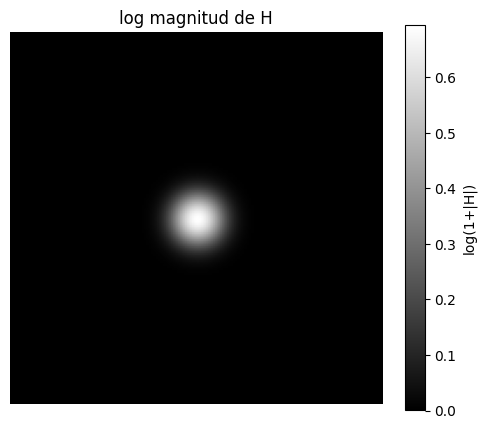

Valor mínimo de |H|: 2.148659681872092e-11
Valor máximo de |H|: 0.9999999999999999


In [10]:
H_full = np.fft.fft2(psf, s=img.shape)
H_mag = np.abs(np.fft.fftshift(H_full))

plt.figure(figsize=(6,5))
plt.imshow(np.log1p(H_mag))
plt.title("log magnitud de H")
plt.colorbar(label="log(1+|H|)")
plt.axis("off")
plt.show()

print("Valor mínimo de |H|:", H_mag.min())
print("Valor máximo de |H|:", H_mag.max())


## 13. Un intento más robusto: filtro de Wiener

Una de las estrategias clásicas para estabilizar la deconvolución es el filtro de Wiener.

Su forma típica es:

$$
\hat{F}(u,v)=\frac{H^*(u,v)}{|H(u,v)|^2+K}G(u,v)
$$

donde:

- $H^*$ es el conjugado complejo de $H$
- $K$ es un parámetro de regularización
- cuando $K$ aumenta, la reconstrucción se hace más estable pero más conservadora

Este filtro no intenta invertir ciegamente todo.  
Introduce un compromiso entre:

- recuperar detalle
- no amplificar demasiado el ruido


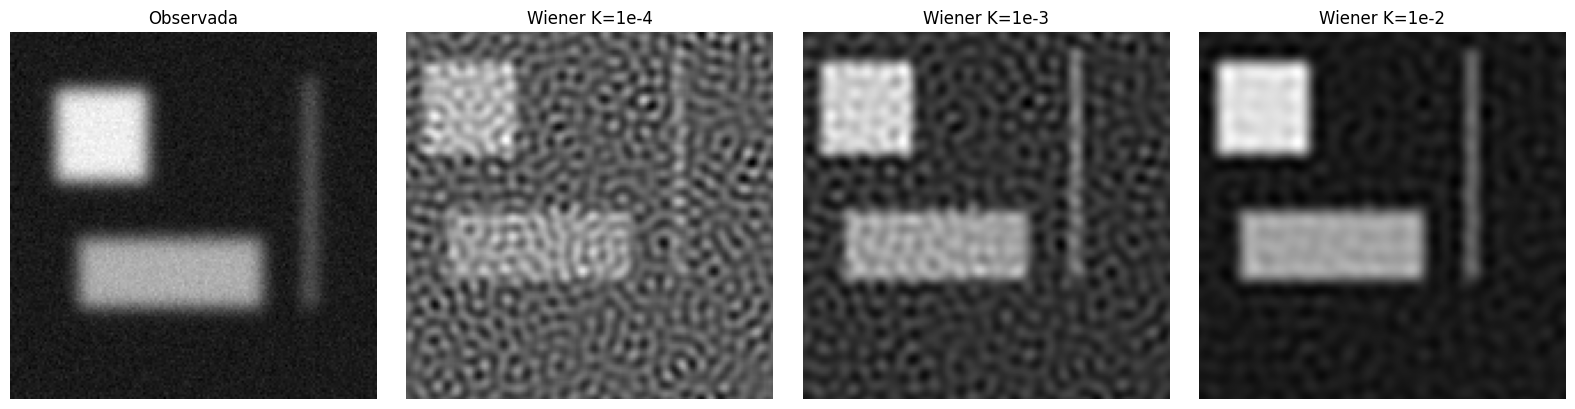

In [11]:
def wiener_deconv(g, h, K=1e-3):
    G = np.fft.fft2(g)
    H = np.fft.fft2(h, s=g.shape)
    H_conj = np.conj(H)
    F_est = (H_conj / (np.abs(H)**2 + K)) * G
    f_est = np.real(np.fft.ifft2(F_est))
    return f_est

rec_wiener_1 = wiener_deconv(img_obs, psf, K=1e-4)
rec_wiener_2 = wiener_deconv(img_obs, psf, K=1e-3)
rec_wiener_3 = wiener_deconv(img_obs, psf, K=1e-2)

plt.figure(figsize=(16,4))

plt.subplot(1,4,1)
plt.imshow(img_obs)
plt.title("Observada")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(rec_wiener_1)
plt.title("Wiener K=1e-4")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(rec_wiener_2)
plt.title("Wiener K=1e-3")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(rec_wiener_3)
plt.title("Wiener K=1e-2")
plt.axis("off")

plt.tight_layout()
plt.show()


### Interpretación del parámetro $K$

- si $K$ es demasiado pequeño, el filtro se parece a la inversión directa y puede amplificar ruido
- si $K$ es demasiado grande, la reconstrucción se vuelve demasiado suave
- elegir $K$ es un equilibrio entre detalle y estabilidad

Aquí aparece una idea fundamental en problemas inversos:

> recuperar información no consiste solo en “invertir”, sino en **regularizar**.


## 14. Comparación global

Comparemos las etapas principales del problema.


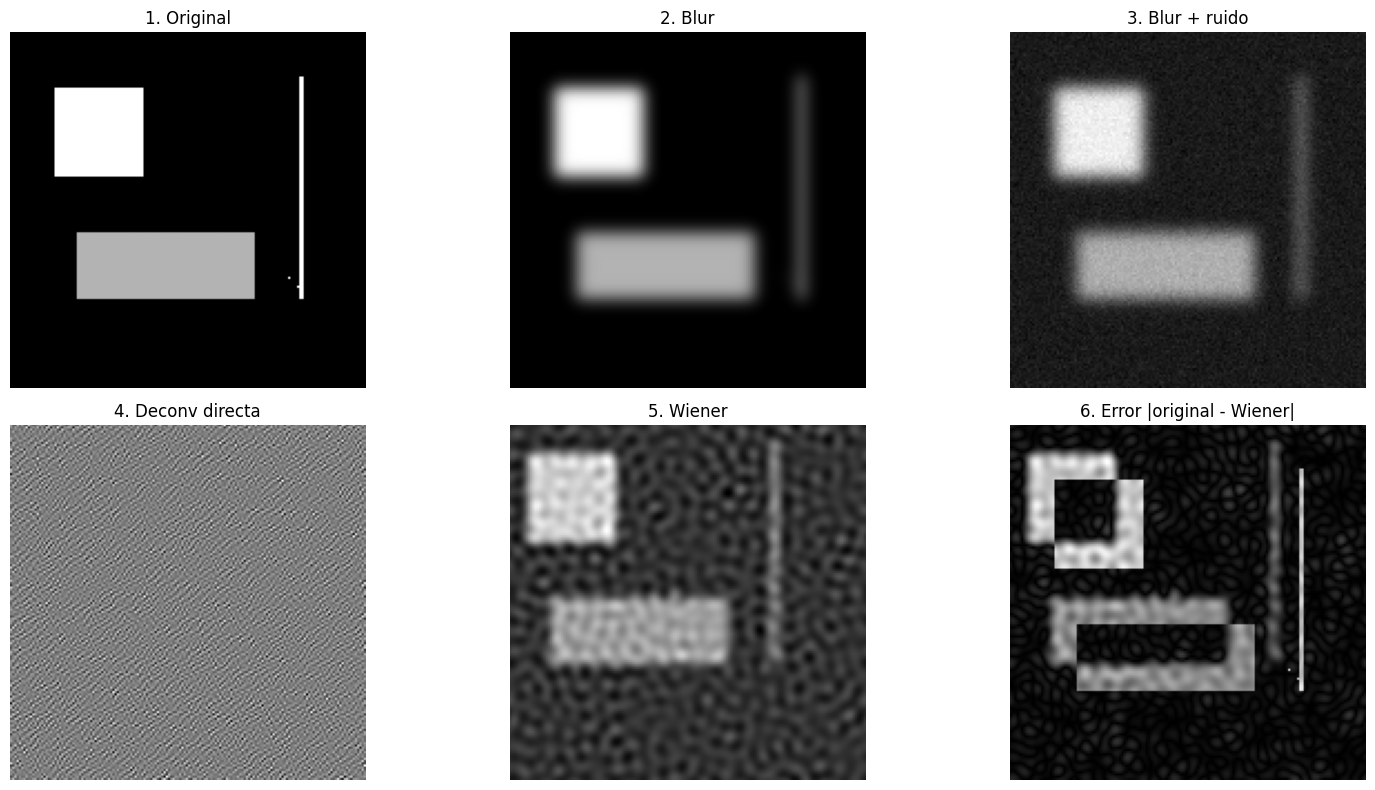

In [12]:
plt.figure(figsize=(16,8))

plt.subplot(2,3,1)
plt.imshow(img, vmin=0, vmax=1)
plt.title("1. Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(img_blur, vmin=0, vmax=1)
plt.title("2. Blur")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(img_obs)
plt.title("3. Blur + ruido")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(rec_direct_noisy)
plt.title("4. Deconv directa")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(rec_wiener_2)
plt.title("5. Wiener")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(np.abs(img - rec_wiener_2))
plt.title("6. Error |original - Wiener|")
plt.axis("off")

plt.tight_layout()
plt.show()


## 15. Medida cuantitativa simple del error

Además de mirar imágenes, es útil cuantificar la calidad de reconstrucción.

Usaremos el error cuadrático medio (MSE):

$$
\text{MSE}=\frac{1}{MN}\sum_{x,y}(f(x,y)-\hat{f}(x,y))^2
$$


In [13]:
def mse(a, b):
    return np.mean((a - b)**2)

mse_blur = mse(img, img_blur)
mse_obs = mse(img, img_obs)
mse_direct = mse(img, rec_direct_noisy)
mse_wiener = mse(img, rec_wiener_2)

print("MSE original vs blur:         ", mse_blur)
print("MSE original vs observada:    ", mse_obs)
print("MSE original vs directa:      ", mse_direct)
print("MSE original vs Wiener:       ", mse_wiener)


MSE original vs blur:          0.014096896311467804
MSE original vs observada:     0.015092771221661859
MSE original vs directa:       7540675416188.763
MSE original vs Wiener:        0.11987589276376044


## 16. Discusión conceptual

A estas alturas ya podemos afirmar varias cosas importantes:

### La convolución no es reversible de forma perfecta en la práctica
Aunque matemáticamente parezca posible invertirla en Fourier, el ruido y la atenuación frecuencial vuelven el problema difícil.

### La PSF actúa como filtro
No todas las frecuencias sobreviven de la misma manera al sistema óptico.

### La deconvolución es un problema inverso mal condicionado
Pequeños errores en la observación pueden transformarse en grandes errores en la reconstrucción.

### La regularización es indispensable
Métodos como Wiener introducen estabilidad a costa de no intentar una inversión brutal y exacta.


## 17. Conexión con aprendizaje profundo

Este capítulo conecta directamente con el aprendizaje profundo para restauración de imágenes.

¿Por qué una CNN puede funcionar en deblurring o deconvolución?

Porque una red puede aprender una aproximación del operador inverso regularizado.

En lugar de hacer:

- inversión directa en Fourier
- o diseñar manualmente toda la regularización

la red aprende a mapear:

$$
g \mapsto \hat{f}
$$

a partir de ejemplos.

Por eso el flujo conceptual es:

1. primero entiendes la física y la matemática del problema  
2. luego entiendes por qué la restauración es difícil  
3. después tiene sentido usar ML como aproximación aprendida del inverso


## 18. Relación con tu proyecto

Este capítulo es central para tu proyecto porque tú no solo quieres analizar imágenes, sino entender cómo sus componentes se degradan y cómo podrían recuperarse o describirse mejor.

Si luego estudias:

- espectros de Fourier
- descomposición angular
- componentes geométricas
- aprendizaje de estructuras

necesitas recordar siempre que lo observado ya está filtrado por una PSF.

En otras palabras:

> antes de aprender componentes de una imagen, hay que entender qué le hizo el sistema a esas componentes.


## 19. Ejercicios sugeridos

1. Cambia el valor de `sigma` en la PSF y repite todo el experimento.  
2. Compara qué estructuras se degradan más: el cuadrado, la línea o los puntos cercanos.  
3. Aumenta el nivel de ruido y analiza el fallo de la deconvolución directa.  
4. Prueba varios valores de `K` en Wiener y describe el compromiso entre nitidez y estabilidad.  
5. Cambia la imagen de prueba por una imagen real en escala de grises y repite el flujo.  
6. Observa el espectro de Fourier de la imagen original y de la degradada, e interpreta qué cambió.


## 20. Conclusiones

En este notebook aprendimos que:

1. la PSF controla cómo se degrada una imagen
2. la convolución redistribuye espacialmente la información
3. en Fourier, la convolución se vuelve multiplicación
4. la deconvolución directa es inestable
5. el filtro de Wiener introduce regularización
6. la restauración de imágenes es un problema inverso mal condicionado
7. esta teoría prepara el terreno para métodos modernos basados en ML

---

## 21. Próximo notebook

**Capítulo 4 — Redes convolucionales para imaging (CNNs)**

Después de entender la física del problema inverso, el siguiente paso natural es estudiar cómo una red convolucional puede aprender transformaciones útiles sobre imágenes y aproximar operadores de restauración.
